# Tutorial 4 — Response times and component lifetimes

## 1. Problem / context

Three kinds of continuous measurement appear constantly in software and hardware:

- a **rounding or polling error** that is spread evenly across a known interval (uniform);
- API **response times** (ms) that cluster around a typical value (normal as a working model);
- component **lifetimes** (h) with a roughly constant failure rate (exponential).

We will compute probabilities with SciPy. We will not integrate densities by hand. Brooks Chapter 4 is the theory reference.

## 2. Densities, CDF, SF, and PPF

For a continuous $X$, $P(X=x)=0$. Probability is **area** under the PDF $f_X$. The CDF is $F_X(x)=P(X\le x)$. SciPy's survival function is $F_X$'s complement: `dist.sf(x)` is $P(X>x)$. The percent-point function `dist.ppf(p)` returns the quantile $x$ with $F_X(x)=p$.

**Uniform** on $[a,b]$: constant density. SciPy uses `uniform(loc=a, scale=b-a)`.

**Normal**: $X\sim N(\mu,\sigma^2)$. SciPy takes `loc=mu` and `scale=sigma` — **standard deviation**, not variance. A $z$-score is

$$
z=\frac{x-\mu}{\sigma}.
$$

Software evaluates $\Phi(z)$ for you; it does not replace the idea of standardising.

**Exponential** with **rate** $\lambda$: $E[T]=1/\lambda$. SciPy uses `expon(scale=1/\lambda)`. Never name the Python variable `lambda`.

A **QQ-plot** compares sample quantiles with model quantiles. It is a diagnostic of shape, not a certificate that the data were generated by that model.

## 3. A short uniform example: rounding error

A sensor reports thickness to the nearest $0.1$ µm. Model the rounding error as $E\sim\mathrm{Uniform}(-0.05,0.05)$ µm.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm, expon, uniform, probplot

round_err = uniform(loc=-0.05, scale=0.10)  # loc=a, scale=b-a
print("P(|E| <= 0.02) =", round_err.cdf(0.02) - round_err.cdf(-0.02))
print("P(E > 0.03) =", round_err.sf(0.03))


P(|E| <= 0.02) = 0.4000000000000001
P(E > 0.03) = 0.20000000000000007


Equal-length subintervals of $[-0.05,0.05]$ are equally likely under this model. That is why a uniform model can be reasonable for rounding or for an unknown phase in a polling cycle, and why it is usually *not* reasonable for thicknesses that cluster around a target.

## 4. Normal response times

When parameters are estimated from `response_times.csv`, the probabilities below are **model-based estimates**: they assume a normal working model with those fitted $\mu$ and $\sigma$, not that the data-generating process is known to be normal.


In [2]:
candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())

times = pd.read_csv(DATA / "response_times.csv")["server_a_ms"]
mu_hat, sigma_hat = times.mean(), times.std(ddof=1)
model = norm(loc=mu_hat, scale=sigma_hat)
print(
    f"N({mu_hat:.2f}, {sigma_hat**2:.2f})  "
    f"[variance shown; SciPy scale is sigma={sigma_hat:.2f} ms]"
)
print("P(X > 140 ms) =", model.sf(140))
print("95th percentile (ms) =", model.ppf(0.95))

z_140 = (140 - mu_hat) / sigma_hat
print(f"z-score for 140 ms = {z_140:.2f}")
print("P(Z > z) via standard normal =", norm.sf(z_140))


N(118.53, 196.89)  [variance shown; SciPy scale is sigma=14.03 ms]
P(X > 140 ms) = 0.06303107200855577
95th percentile (ms) = 141.61418379252802
z-score for 140 ms = 1.53
P(Z > z) via standard normal = 0.06303107200855577


The last two printed probabilities should agree: `model.sf(140)` is the same calculation as standardising and then using `norm.sf(z)`. Tables of $\Phi$ are doing the same job; SciPy replaces the table lookup.


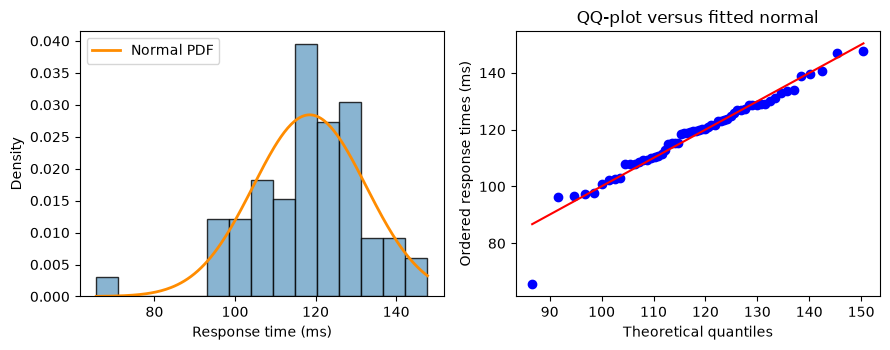

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
xs = np.linspace(times.min(), times.max(), 200)
axes[0].hist(times, bins=15, density=True, edgecolor="black", color="#6CA2C6", alpha=0.8)
axes[0].plot(xs, model.pdf(xs), color="#FF8C00", lw=2, label="Normal PDF")
axes[0].set_xlabel("Response time (ms)")
axes[0].set_ylabel("Density")
axes[0].legend()
probplot(times, dist=model, plot=axes[1])
axes[1].set_title("QQ-plot versus fitted normal")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Ordered response times (ms)")
plt.tight_layout()
plt.show()


Read the QQ-plot as evidence about **adequacy**, not as a pass/fail proof of normality. Random scatter about the line is compatible with the working model. Systematic curvature, especially in the tails, means the normal tail probability is a rougher approximation. A model that describes the centre well can still be a poor model for a rare exceedance.

Pause: if the right-hand QQ points bend above the line in the upper tail, is `model.sf(140)` more likely to understate or overstate the chance of a slow request?

## 5. Exponential lifetimes


In [4]:
life = pd.read_csv(DATA / "component_lifetimes.csv")["lifetime_h"]
mean_life = life.mean()
rate = 1 / mean_life
wait = expon(scale=1 / rate)
print(f"rate = {rate:.4f} per hour, mean = {mean_life:.1f} h")
print("P(T > 600 h) =", wait.sf(600))
print("P(T < 100 h) =", wait.cdf(100))


rate = 0.0030 per hour, mean = 330.1 h
P(T > 600 h) = 0.16244201172143513
P(T < 100 h) = 0.2613312494465135


Again these are model-based estimates: $\lambda$ is estimated by $1/\bar{t}$, and `expon(scale=1/rate)` is SciPy's scale $1/\lambda$. The exponential model assumes a constant rate; that is a modelling choice, not something the data prove.

## 6. Common mistakes / things to notice

- Passing variance to `norm(scale=...)`. Scale is $\sigma$, not $\sigma^2$.
- Writing $X\sim N(\mu,\sigma)$ in mathematics. In this course: $N(\mu,\sigma^2)$.
- `uniform(loc=a, scale=b)` when you meant the interval $[a,b]$. The scale is the **width** $b-a$.
- `expon(scale=rate)` — that is the wrong parameterisation.
- Treating a QQ-plot as a proof of normality.
- Integrating $f(x)$ by hand in STA1. Use `cdf` / `sf`.

## 7. Short worked example

Noise on a voltage measurement is modelled as $N(5.00, 0.02^2)$ V. Find $P(4.96 \le X \le 5.04)$ and the 99th percentile.


In [5]:
volt = norm(loc=5.00, scale=0.02)
print(volt.cdf(5.04) - volt.cdf(4.96))
print(volt.ppf(0.99))


0.9544997361036418
5.0465269574808165


**Conclusion:** Uniform, normal, and exponential models answer different physical stories. SciPy evaluates area, tail, and quantile once the parameterisation is stated correctly — `scale` is $\sigma$ for the normal and $1/\lambda$ for the exponential — and a QQ-plot can only say whether that working model looks adequate for the question at hand.
